**CAMB Python example notebook**

Run it online yourself in [Binder](https://mybinder.org/v2/gh/cmbant/camb/master?filepath=docs%2FCAMBdemo.ipynb).

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import camb
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect

Using CAMB 1.5.8 installed at /Users/zhouxue/Desktop/WMG/code/CAMB/camb


In [3]:
# make sure the version and path is what you expect
# Energy density unit conversion
Mpc = 3.085678e22
c = 2.99792458e8
G = 6.6738e-11
kappa = 8 * np.pi * G
hplanck = 6.62606896e-34
hbar = hplanck/2/np.pi
Tpl = np.sqrt(kappa*hbar/c**5)
energyunitconversion = Mpc**2/(c**2 * Tpl**2)


In [5]:
#Set up a new set of parameters for CAMB
#The defaults give one massive neutrino and helium set using BBN consistency
lcdmcosmology = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
lcdmresults = camb.get_results(lcdmcosmology)
lcdmcls = lcdmresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
lcdmks = lcdmresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
lcdmpks = lcdmresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
lcdmpowers =lcdmresults.get_cmb_power_spectra(lcdmcosmology, CMB_unit='muK')


[5.53022167e-13 3.14579468e-10 2.27565709e-09 ... 6.81804855e-01
 6.82130589e-01 6.82455981e-01]
[9.99900000e+03 1.66511102e+03 9.07760285e+02 ... 1.00140200e-03
 5.00450425e-04 0.00000000e+00]


CAMBError: Error in Fortran called from calc_transfer:
Dverk error -3: the subroutine was unable  to  satisfy  the  error requirement  with a particular step-size that is less than or * equal to hmin, which may mean that tol is too small--- but most likely you've messed up the y array indexing; compiling with bounds checking may (or may not) help find the problem.

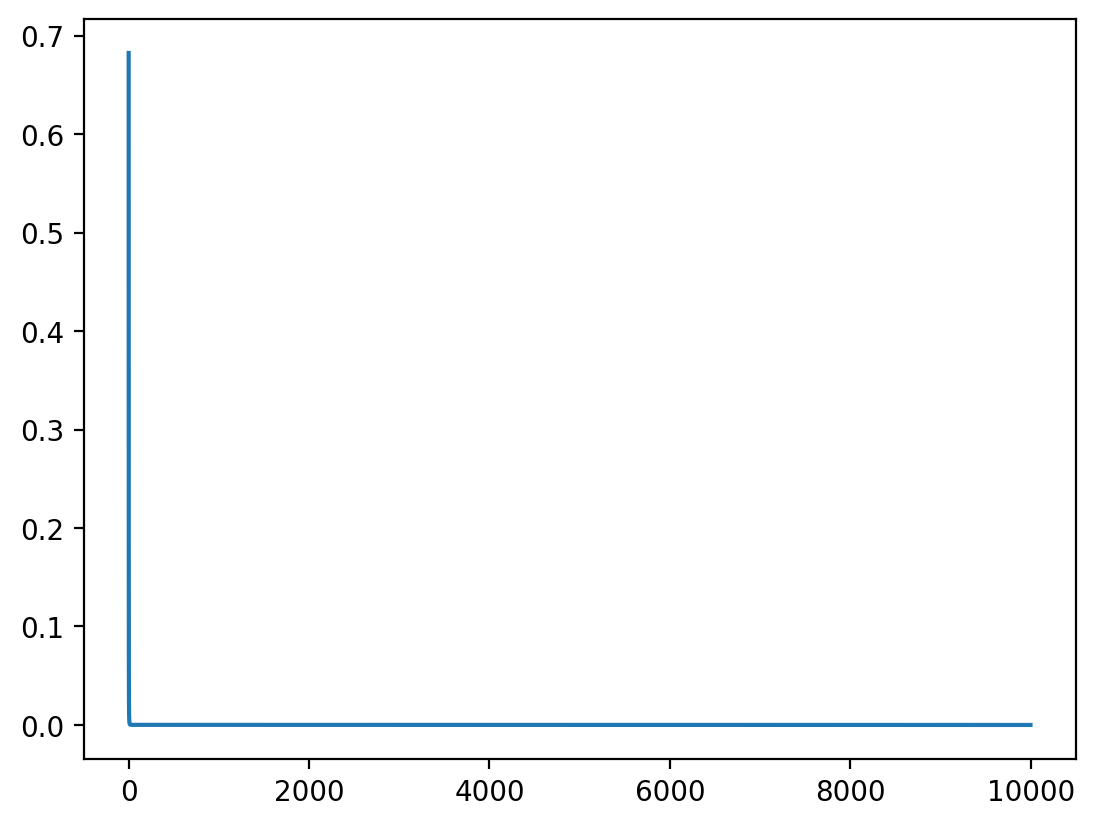

In [9]:
Ms = [0, -0.001,-0.01]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,N=0.1,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    scales = np.array(np.linspace(10**(-4), 1, 2000))
    omegaphis = gpnresults.get_Omega('de', z = 1/scales - 1)
    omegaphis = gpnresults.get_Omega('de', z = 1/scales - 1)
    redshifts = 1/scales - 1
    print(omegaphis)
    print(redshifts)
    plt.plot(redshifts, omegaphis)

plt.plot(redshifts,omegaphis)
plt.xscale('log')
plt.xlim([0, 10**6])
plt.title('Dark Energy Fraction Evolution')
plt.xlabel(r'$z$')
plt.ylabel(r'$\Omega_\phi$')
plt.legend(legends)
plt.grid()
plt.savefig('rocknroll_5_omegaphis.pdf')
plt.show()

[0. 0. 0. ... 0. 0. 0.]
[1.00000000e-06 5.01249625e-04 1.00149925e-03 ... 9.98999501e-01
 9.99499750e-01 1.00000000e+00]
[0. 0. 0. ... 0. 0. 0.]
[1.00000000e-06 5.01249625e-04 1.00149925e-03 ... 9.98999501e-01
 9.99499750e-01 1.00000000e+00]
[0. 0. 0. ... 0. 0. 0.]
[1.00000000e-06 5.01249625e-04 1.00149925e-03 ... 9.98999501e-01
 9.99499750e-01 1.00000000e+00]


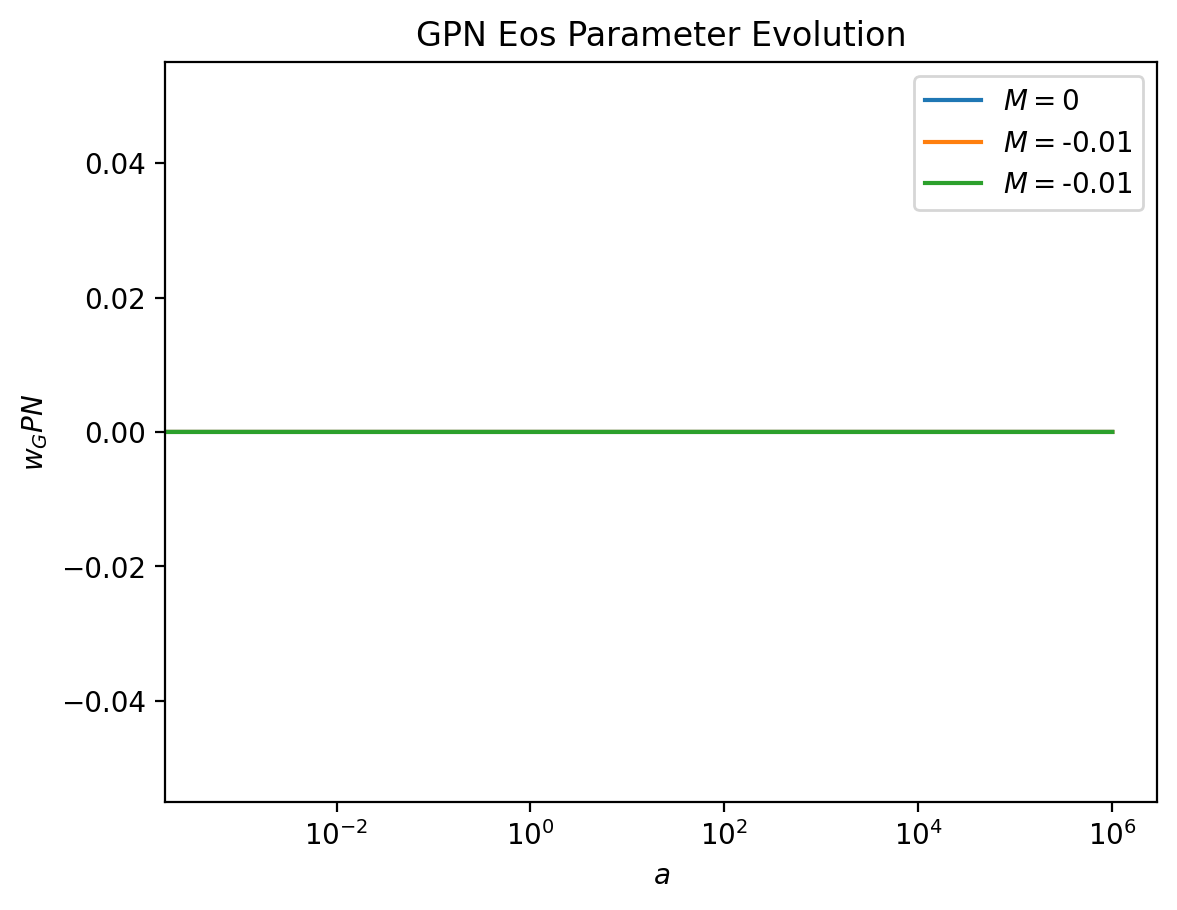

In [41]:
Ms = [0, -0.01, -0.01]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,N=0.1,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    scales =  np.array(np.linspace(10**(-6), 1, 2000))
    redshifts = 1/scales - 1
    w = gpnresults.get_dark_energy_rho_w(scales )[1]
    print(w)
    print(scales)
    plt.plot(redshifts, w)

plt.xscale('log')
#plt.xlim([0, 10**6])
plt.title('GPN Eos Parameter Evolution')
plt.xlabel(r'$a$')
plt.ylabel(r'$w_GPN$')
plt.legend(legends)
plt.savefig('rocknroll_5_wphis.pdf')
plt.show()


For further details of camb.symbolic and examples of what can be done see the [CAMB symbolic ScalEqs notebook](https://camb.readthedocs.io/en/latest/ScalEqs.html) (run now in [Binder](https://mybinder.org/v2/gh/cmbant/camb/master?filepath=docs%2FScalEqs.ipynb)). This also serves as documentation for the scalar equations implemented in CAMB.

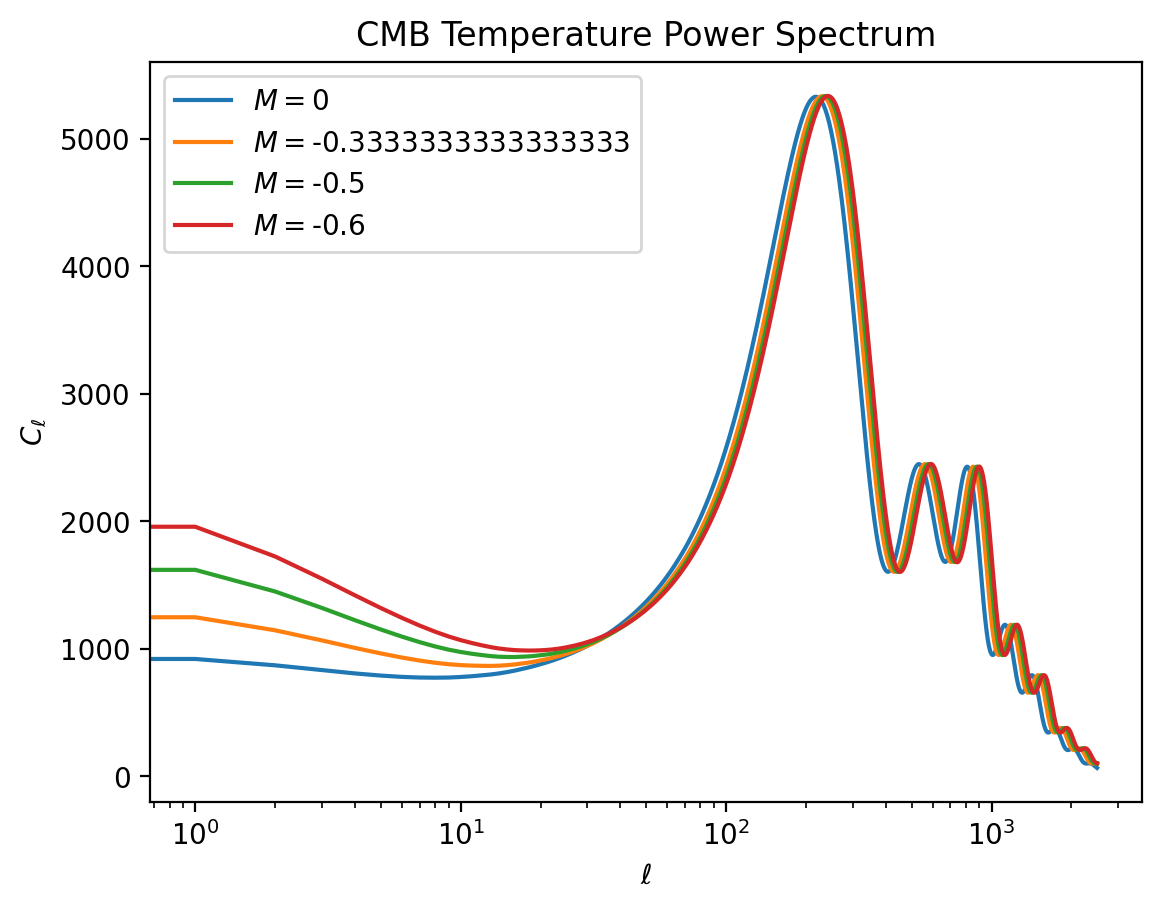

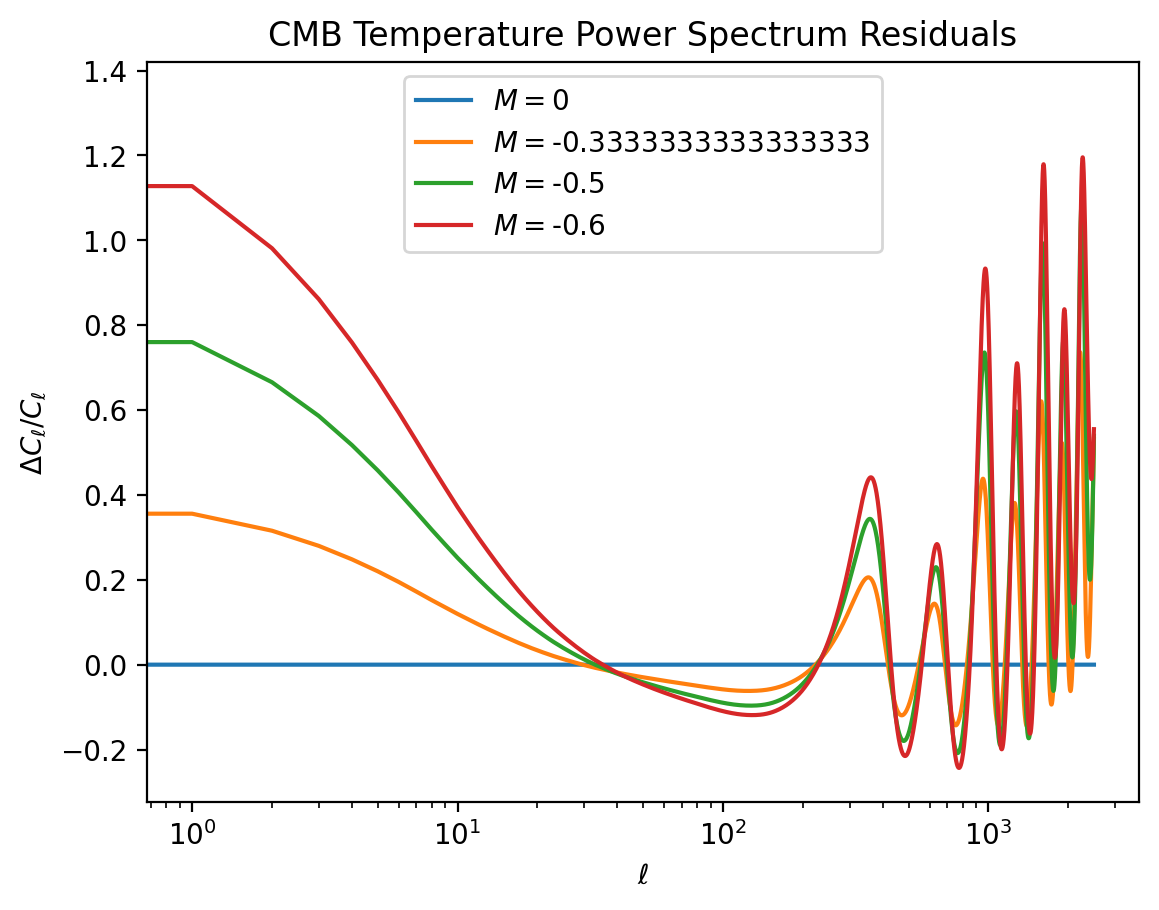

In [8]:
Ms = [0, -1/3, -0.5, -0.6]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    plt.plot(gpncls[2:])

plt.xscale('log')
plt.title('CMB Temperature Power Spectrum')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.legend(legends)
plt.show()

Ms = [0, -1/3, -0.5, -0.6]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    plt.plot((gpncls[2:]-lcdmcls[2:])/lcdmcls[2:])

plt.xscale('log')
plt.title('CMB Temperature Power Spectrum Residuals')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell / C_\ell$')
plt.legend(legends)
plt.show()


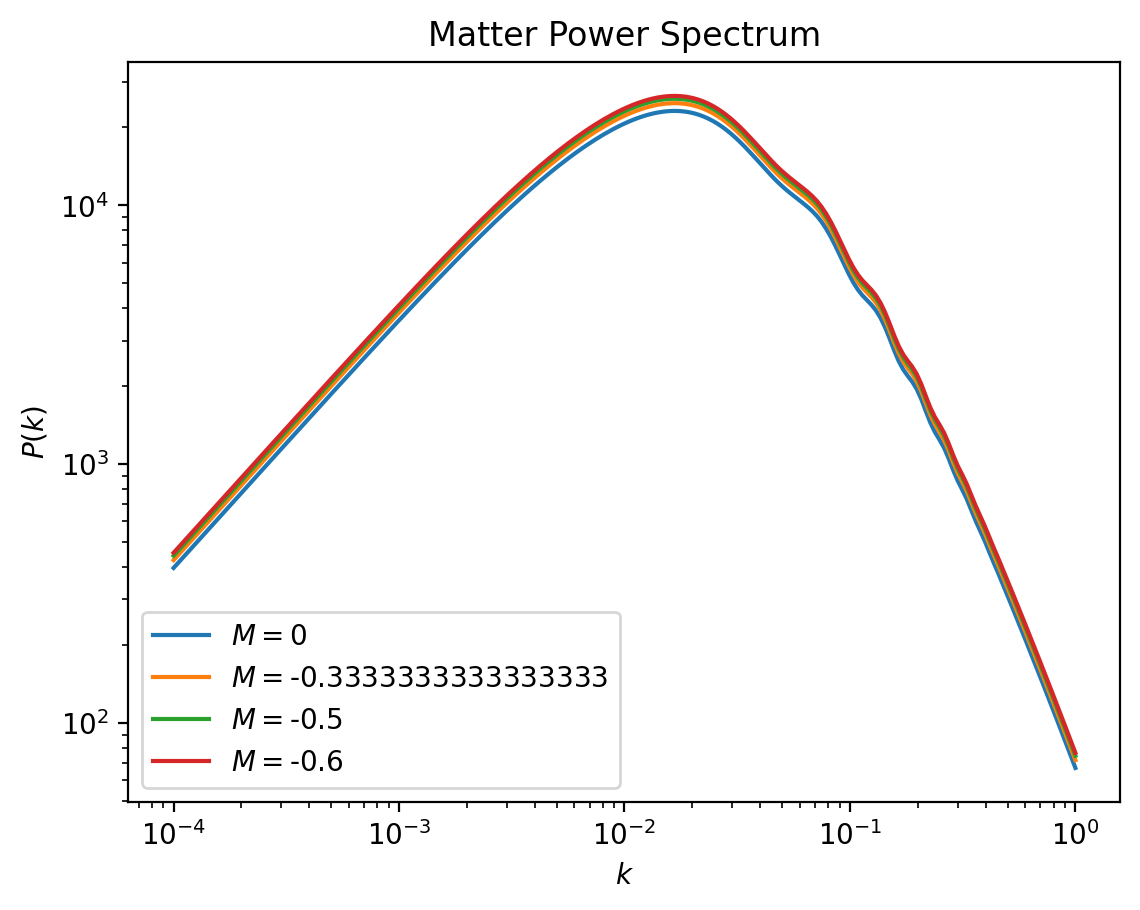

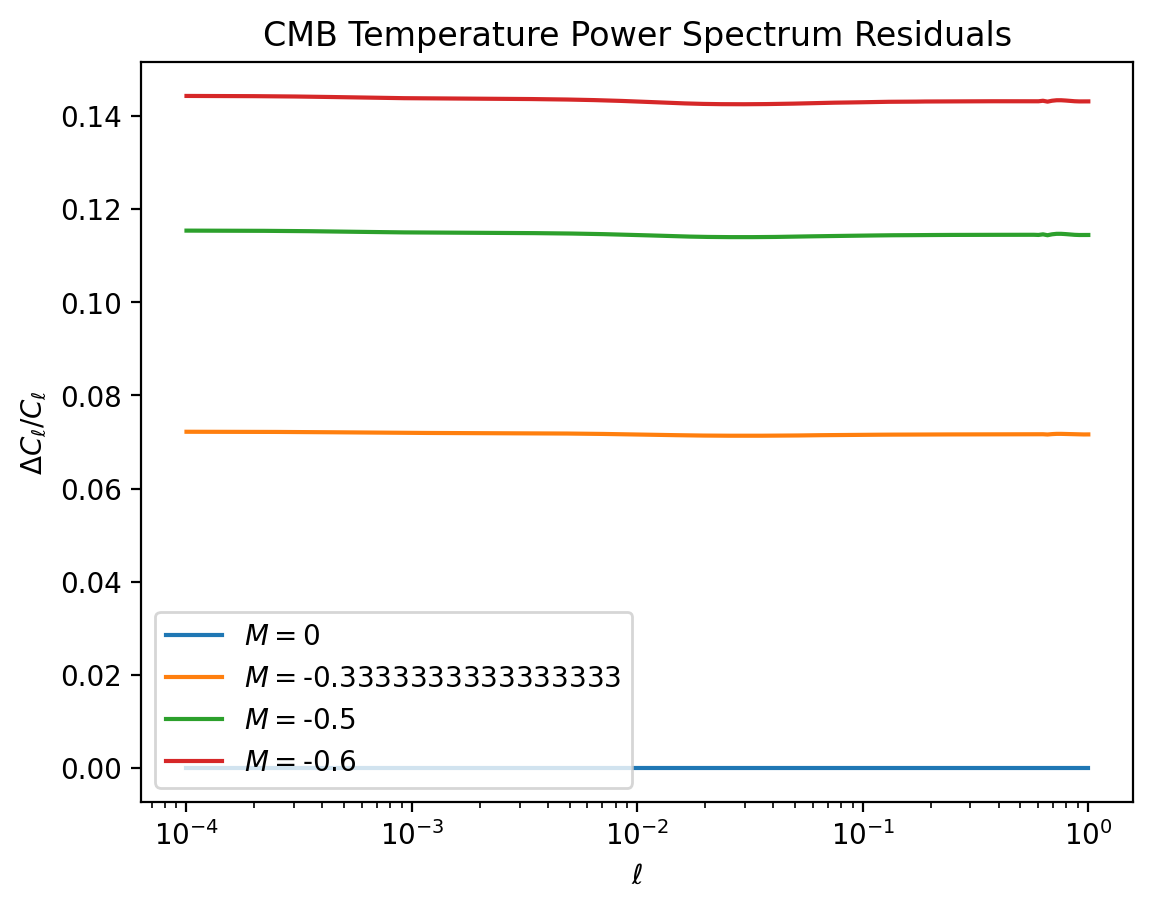

In [9]:
Ms = [0, -1/3, -0.5, -0.6]
i = [0, 0.022, 1, 3]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    plt.plot(gpnks, gpnpks[0,:])

plt.xscale('log')
plt.yscale('log')
plt.title('Matter Power Spectrum')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.legend(legends)
plt.show()

Ms = [0, -1/3, -0.5, -0.6]
legends = [r'$M = $'+ str(x) for x in Ms]
for M in Ms:
    
    gpncosmology=camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,M=M,
                       As=2e-9, ns=0.965, halofit_version='mead', WantTransfer=True)
    gpnresults = camb.get_results(gpncosmology)
    gpncls = gpnresults.get_unlensed_scalar_cls(CMB_unit = 'muK')[:,0]
    gpnks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[0]
    gpnpks = gpnresults.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)[2]
    gpnpowers =gpnresults.get_cmb_power_spectra(gpncosmology, CMB_unit='muK')
    plt.plot(gpnks, (gpnpks[0,:] - lcdmpks[0,:])/lcdmpks[0,:])

plt.xscale('log')
plt.title('CMB Temperature Power Spectrum Residuals')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell / C_\ell$')
plt.legend(legends)
plt.show()
